## Q8: Game of Life visualization

In [32]:
import game_of_life_funcs as f
import importlib
importlib.reload(f)
import numpy as np

For now I still can't set up a configuration of the game that lasts forever, so there is no point in doing a lot of iterations because the system dies anyway

In [35]:
generator = np.random.default_rng()
my_grid = generator.integers(low = 0, high=1, endpoint = True, size = (100,100))
f.play_life_game_wplots(my_grid, 100)

In [36]:
import matplotlib.pyplot as plt

## Q3: A perfect circle

For an angle $\theta$ in the range $\theta \in [0, 2\pi]$, the polar equations of a circle of radius $R$ are:

$$x = R\cos(\theta)$$

$$y = R\sin(\theta)$$

We want to draw a circle.   

  * Create an array to hold the theta values&mdash;the more we use, the smoother the circle will be
  * Create `x` and `y` arrays from `theta` for your choice of $R$
  * Plot `y` vs. `x`
  
Now, look up the matplotlib `fill()` function, and draw a circle filled in with a solid color.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [2]:
plt.style.use("fivethirtyeight")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Courier"
})


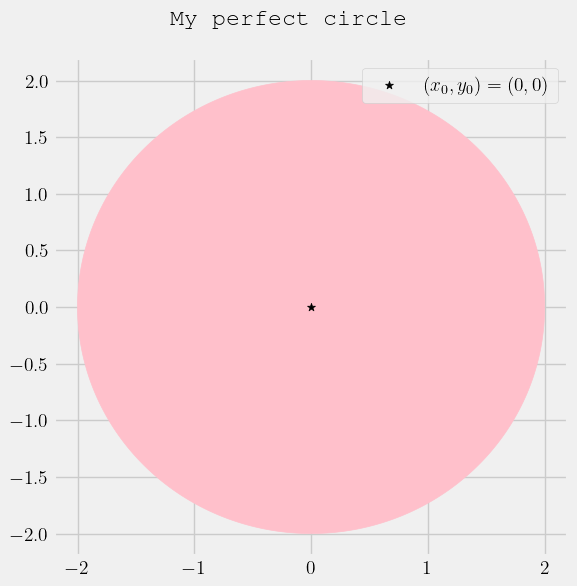

In [3]:
theta = np.linspace(0, 2*np.pi, 500)
x = np.array([2*np.cos(i) for i in theta])
y = np.array([2*np.sin(i) for i in theta])

fig = plt.figure(figsize = (6,6))
fig.suptitle(r"My perfect circle")
ax = fig.add_subplot(111)
ax.fill(x,y, color = "pink")
ax.scatter(0, 0, label = r'$(x_0,y_0) = (0,0)$', marker= '*', color = "black")
ax.legend(loc = "upper right")
fig.tight_layout()


Generalize your circle drawing commands to produce a function, 
```
draw_circle(x0, y0, R, color)
```
that draws the circle.  Here, `(x0, y0)` is the center of the circle, `R` is the radius, and `color` is the color of the circle.  

Now randomly draw 10 circles at different locations, with random radii, and random colors on the same plot.

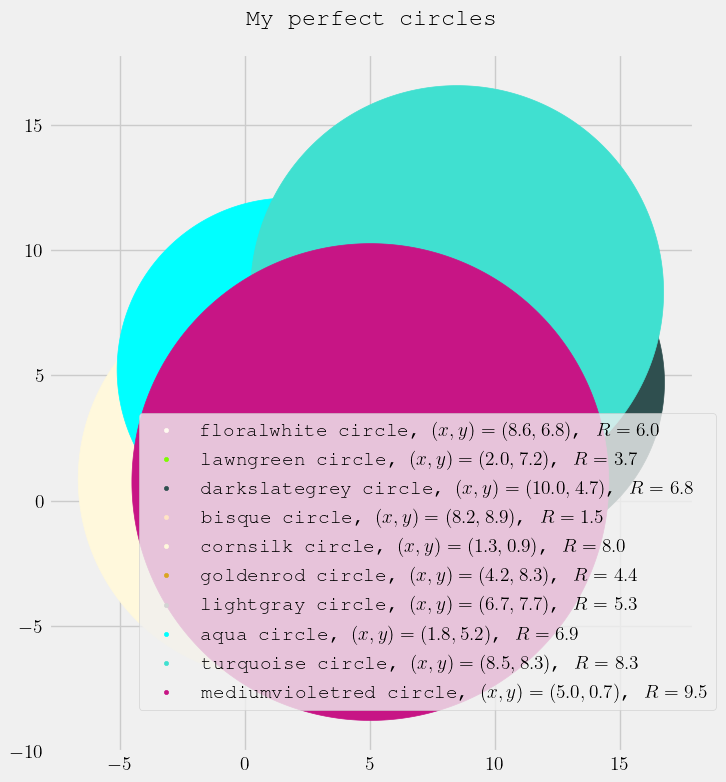

In [8]:
fig = plt.figure(figsize = (8,8))
fig.suptitle(r"My perfect circles")
ax = fig.add_subplot(111)

#the bounds of this random generator can, of course, be changed
x0_vals = [np.random.uniform(0, 10) for _ in range(10)]
y0_vals = [np.random.uniform(0, 10) for _ in range(10)]
radii_vals = [np.random.uniform(1, 10) for _ in range(10)]
#there is 148 colors in the CSS4 list so we just select some random ones
generator = np.random.default_rng()
cix = np.array(generator.integers(low = 0, high=147, endpoint = True, size = 10))
colors = [list(mcolors.CSS4_COLORS.keys())[index] for index in cix] 

def draw_circle(x0, y0, R, color):

    x = np.array([x0 + R*np.cos(i) for i in theta])
    y = np.array([y0 + R*np.sin(i) for i in theta])

    ax.fill(x , y , color = color)
    ax.scatter(x0, y0, label = color + rf" circle, $(x,y) = ({x0:.1f},{y0:.1f})$, $R = {R:.1f}$", marker= '.', color = color)

#this loop is inevitable, right?
_ = [draw_circle(x0, y0, r, c) for x0, y0, r, c in zip(x0_vals, y0_vals, radii_vals, colors)]
ax.legend(loc = "upper right", bbox_to_anchor=(1.05, 0.5),)
ax.set_aspect('equal', adjustable='box')
fig.tight_layout()
